# AI-Based Lead Scoring & Analytics System
This notebook trains and evaluates lead conversion models using the UCI Bank Marketing **bank-full.csv** dataset.

**Dataset required:** `../data/bank-full.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay
import joblib
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DROP_LEAKY_FEATURES = True
LEAKY_COLUMNS = ['duration']  # duration is only known after a call; remove for realistic pre-call scoring


In [2]:
data_path = Path('../data/bank-full.csv')
if not data_path.exists():
    raise FileNotFoundError('Missing ../data/bank-full.csv. Download bank-full.csv from UCI and place it in lead_scoring_project/data/')
df = pd.read_csv(data_path, sep=';')
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print(df['y'].value_counts(normalize=True))
display(df.describe(include='all').transpose().head(20))

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


/var/folders/98/k_m6kcxn1vdcwfflj04d6l1r0000gp/T/ipykernel_29824/388787667.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', ax=axes[1], palette='viridis')


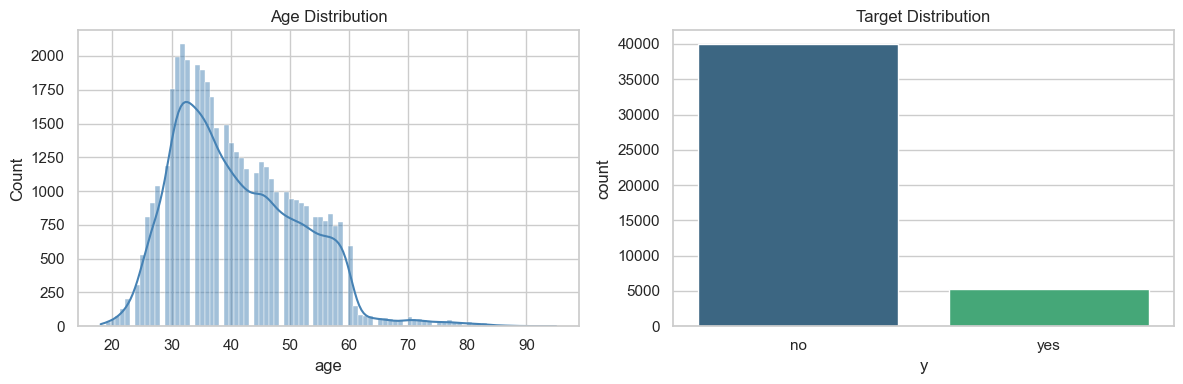

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
sns.countplot(data=df, x='y', ax=axes[1], palette='viridis')
axes[1].set_title('Target Distribution')
plt.tight_layout()
plt.show()

In [5]:
df = df.drop_duplicates().copy()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

if DROP_LEAKY_FEATURES:
    df = df.drop(columns=[c for c in LEAKY_COLUMNS if c in df.columns])

print('Columns used:', df.columns.tolist())
df.isna().sum().sum()

Columns used: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


0

In [6]:
X = df.drop(columns=['y'])
y = (df['y'].str.lower() == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (36168, 15) Test: (9043, 15)


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ]
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, class_weight='balanced')
}

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'roc_auc']

cv_rows = []
trained_models = {}
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_rows.append({
        'model': name,
        'cv_accuracy_mean': scores['test_accuracy'].mean(),
        'cv_precision_mean': scores['test_precision'].mean(),
        'cv_recall_mean': scores['test_recall'].mean(),
        'cv_roc_auc_mean': scores['test_roc_auc'].mean(),
    })

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

cv_results_df = pd.DataFrame(cv_rows).sort_values('cv_roc_auc_mean', ascending=False)
cv_results_df

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_roc_auc_mean
1,Random Forest,0.892668,0.624607,0.206098,0.779990
0,Logistic Regression,0.892170,0.644637,0.174902,0.762827


Best model from CV: Random Forest
Holdout metrics: {'accuracy': 0.8943934534999447, 'precision': 0.6501457725947521, 'recall': 0.2107750472589792, 'roc_auc': 0.7938727268638149}


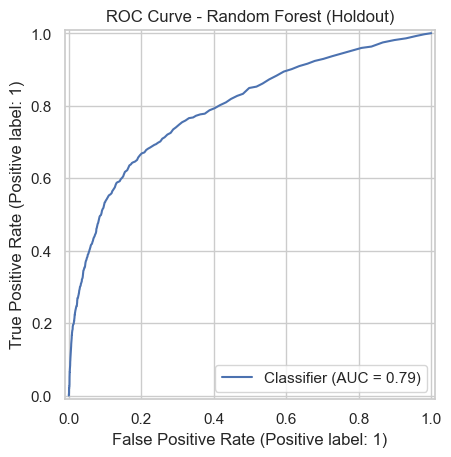

In [9]:
best_model_name = cv_results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

holdout_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob),
}

print('Best model from CV:', best_model_name)
print('Holdout metrics:', holdout_metrics)
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f'ROC Curve - {best_model_name} (Holdout)')
plt.show()

In [10]:
model_bundle = {
    'model': best_model,
    'feature_columns': X.columns.tolist(),
    'selected_model': best_model_name,
    'cv_metrics': cv_results_df.to_dict(orient='records'),
    'holdout_metrics': holdout_metrics,
    'dataset': 'UCI Bank Marketing - bank-full.csv',
}
joblib.dump(model_bundle, '../backend/model.pkl')
print('Saved model to ../backend/model.pkl')

Saved model to ../backend/model.pkl
